
# MT5 EURUSD 5m — Análisis del 11/09/2025

Este notebook descarga velas **5 minutos** de **EURUSD** desde **MetaTrader 5 (MT5)** para el **11 de septiembre de 2025** y ejecuta un análisis cuantitativo con **retornos**, **tests estadísticos**, **ARIMA** y **GARCH**.

> **Requisitos previos**: Tener **MetaTrader 5** instalado y **sesión iniciada** en tu cuenta (demo o real) en el mismo equipo donde ejecutas este notebook.



## Instalación de dependencias

Ejecuta esta celda si aún no tienes instaladas estas librerías.


In [1]:

# Puedes ejecutar una por una si lo prefieres
%pip install MetaTrader5 pandas numpy matplotlib scipy statsmodels arch


Note: you may need to restart the kernel to use updated packages.


## Configuración

In [2]:

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from datetime import datetime

# --- Parámetros ---
SYMBOL = "EURUSD"                       # Símbolo en MT5
DATE   = pd.Timestamp("2025-09-16")     # Día a analizar
TIMEFRAME_MINUTES = 5                   # 5 minutos
LOCAL_TZ = "America/New_York"             # Tu zona horaria
SAVE_CSV = True                         # Guardar CSV resultante

# Para reproducibilidad en algunos cálculos
np.random.seed(42)


## Descarga de datos desde MT5 (5m)

In [3]:

import MetaTrader5 as mt5

# Inicializar MT5
if not mt5.initialize():
    raise RuntimeError(f"Error inicializando MT5: {mt5.last_error()}")

# Seleccionar timeframe (5 minutos)
TIMEFRAME_MAP = {
    1: mt5.TIMEFRAME_M1, 2: mt5.TIMEFRAME_M2, 3: mt5.TIMEFRAME_M3, 4: mt5.TIMEFRAME_M4, 5: mt5.TIMEFRAME_M5,
    10: mt5.TIMEFRAME_M10, 15: mt5.TIMEFRAME_M15, 30: mt5.TIMEFRAME_M30, 60: mt5.TIMEFRAME_H1
}
TIMEFRAME = TIMEFRAME_MAP.get(TIMEFRAME_MINUTES, mt5.TIMEFRAME_M5)

# Rango del día completo (horas locales convertidas a naïve -> MT5 interpreta como UTC epoch seconds)
from datetime import datetime

utc_from = datetime(DATE.year, DATE.month, DATE.day, 0, 0)
utc_to   = datetime(DATE.year, DATE.month, DATE.day, 23, 59)

rates = mt5.copy_rates_range(SYMBOL, TIMEFRAME, utc_from, utc_to)
mt5.shutdown()

if rates is None or len(rates) == 0:
    raise RuntimeError("No se pudieron descargar velas (¿mercado cerrado, símbolo incorrecto o MT5 no logueado?).")

df = pd.DataFrame(rates)
df['time'] = pd.to_datetime(df['time'], unit='s', utc=True)  # MT5 entrega epoch segundos (UTC)
df = df.set_index('time').sort_index()

# Renombrar a OHLCV estándar; usar tick_volume como Volume
df = df.rename(columns={
    "open": "Open",
    "high": "High",
    "low": "Low",
    "close": "Close",
    "tick_volume": "Volume"
})[["Open","High","Low","Close","Volume"]]

# Convertir índice a tu zona horaria
df.index = df.index.tz_convert(LOCAL_TZ)

print(df.head())
print(f"Filas 5m en {DATE.date()}: {len(df)}")


                              Open     High      Low    Close  Volume
time                                                                 
2025-09-16 01:00:00-04:00  1.17669  1.17692  1.17667  1.17688     180
2025-09-16 01:05:00-04:00  1.17688  1.17721  1.17681  1.17697     245
2025-09-16 01:10:00-04:00  1.17698  1.17717  1.17693  1.17712     218
2025-09-16 01:15:00-04:00  1.17712  1.17747  1.17705  1.17741     263
2025-09-16 01:20:00-04:00  1.17741  1.17767  1.17730  1.17731     245
Filas 5m en 2025-09-16: 288


### (Opcional) Guardar CSV

In [4]:

if SAVE_CSV:
    out_path = f"EURUSD_{DATE.date()}_5mTesT.csv"
    df.to_csv(out_path, index_label="Datetime")
    print(f"CSV guardado en: {out_path}")



CSV guardado en: EURUSD_2025-09-16_5mTesT.csv


## Retornos y descriptivos

In [22]:

# Retornos logarítmicos
df['ret'] = np.log(df['Close']).diff()
rets = df['ret'].dropna()

print("=== Descriptivos de retornos (log) ===")
print(rets.describe())
print(f"Skew: {rets.skew():.4f} | Kurtosis(exceso): {rets.kurtosis():.4f}")


=== Descriptivos de retornos (log) ===
count    287.000000
mean       0.000008
std        0.000285
min       -0.000835
25%       -0.000094
50%       -0.000009
75%        0.000094
max        0.002804
Name: ret, dtype: float64
Skew: 3.4169 | Kurtosis(exceso): 33.3845


## Tests estadísticos (ADF, Ljung-Box, normalidad)

In [23]:

from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy import stats

# ADF
try:
    adf_stat, adf_p, *_ = adfuller(rets, autolag="AIC")
    print(f"ADF: stat={adf_stat:.4f}, p={adf_p:.4g} -> p<0.05 sugiere estacionariedad")
except Exception as e:
    print(f"ADF falló: {e}")

# Ljung-Box
try:
    lb_ret = acorr_ljungbox(rets, lags=[12], return_df=True)
    lb_sq  = acorr_ljungbox(rets**2, lags=[12], return_df=True)
    print("\nLjung-Box retornos:")
    print(lb_ret.to_string(index=False))
    print("\nLjung-Box retornos^2 (heterocedasticidad):")
    print(lb_sq.to_string(index=False))
except Exception as e:
    print(f"Ljung-Box falló: {e}")

# Normalidad
try:
    jb_stat, jb_p = stats.jarque_bera(rets)
    print(f"\nJarque-Bera: stat={jb_stat:.4f}, p={jb_p:.4g}")
except Exception as e:
    print(f"Jarque-Bera falló: {e}")


ADF: stat=-5.7856, p=5.008e-07 -> p<0.05 sugiere estacionariedad

Ljung-Box retornos:
  lb_stat  lb_pvalue
48.095005   0.000003

Ljung-Box retornos^2 (heterocedasticidad):
 lb_stat  lb_pvalue
26.13162   0.010283

Jarque-Bera: stat=13406.0236, p=0


## ARIMA (búsqueda simple por BIC)

In [24]:

from statsmodels.tsa.arima.model import ARIMA
best_bic, best_order, arima_res = np.inf, None, None

# Grid pequeña p,q ∈ {0,1,2} con d=0 (retornos)
for p in range(0,3):
    for q in range(0,3):
        try:
            fit = ARIMA(rets, order=(p,0,q)).fit(method_kwargs={"warn_convergence": False})
            if fit.bic < best_bic:
                best_bic, best_order, arima_res = fit.bic, (p,0,q), fit
        except Exception:
            pass

if arima_res is not None:
    print(f"Mejor ARIMA{best_order} BIC={best_bic:.2f}")
    display(arima_res.summary())
else:
    print("ARIMA no convergió en la malla probada.")


Mejor ARIMA(0, 0, 0) BIC=-3860.34


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                    ret   No. Observations:                  287
Model:                          ARIMA   Log Likelihood                1935.829
Date:                Wed, 17 Sep 2025   AIC                          -3867.658
Time:                        21:17:06   BIC                          -3860.339
Sample:                    09-11-2025   HQIC                         -3864.724
                         - 09-12-2025                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       3.057e-06    2.1e-05      0.145      0.884   -3.82e-05    4.43e-05
sigma2      8.259e-08   2.06e-09     40.048      0.000    7.85e-08    8.66e-08
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):             13406.02
Prob(Q):                              0.97   Prob(JB):                         0.00
Heteroskedasticity (H):               0.49   Skew:                             3.40
Prob(H) (two-sided):                  0.00   Kurtosis:                        35.78
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

## GARCH(1,1) en retornos (%)

In [25]:

from arch import arch_model

garch_res = None
try:
    y = rets * 100.0  # escalar a %
    am = arch_model(y, mean='constant', vol='GARCH', p=1, o=0, q=1, dist='normal')
    garch_res = am.fit(disp="off")
    display(garch_res.summary())
except Exception as e:
    print(f"GARCH falló: {e}")


<class 'statsmodels.iolib.summary.Summary'>
"""
                     Constant Mean - GARCH Model Results                      
==============================================================================
Dep. Variable:                    ret   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:                702.009
Distribution:                  Normal   AIC:                          -1396.02
Method:            Maximum Likelihood   BIC:                          -1381.38
                                        No. Observations:                  287
Date:                Wed, Sep 17 2025   Df Residuals:                      286
Time:                        21:17:06   Df Model:                            1
                                  Mean Model                                  
==============================================================================
                  coef    std err          t      P>|t|       95.0% Conf. Int.
------------------------------------------------------------------------------
mu         -5.3550e-04  1.097e-03     -0.488      0.625 [-2.685e-03,1.614e-03]
                              Volatility Model                              
============================================================================
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
omega      1.6213e-05  2.076e-10  7.811e+04      0.000 [1.621e-05,1.621e-05]
alpha[1]       0.2000  9.561e-02      2.092  3.646e-02   [1.260e-02,  0.387]
beta[1]        0.7800  5.687e-02     13.715  8.255e-43     [  0.669,  0.891]
============================================================================

Covariance estimator: robust
"""

## Gráficos

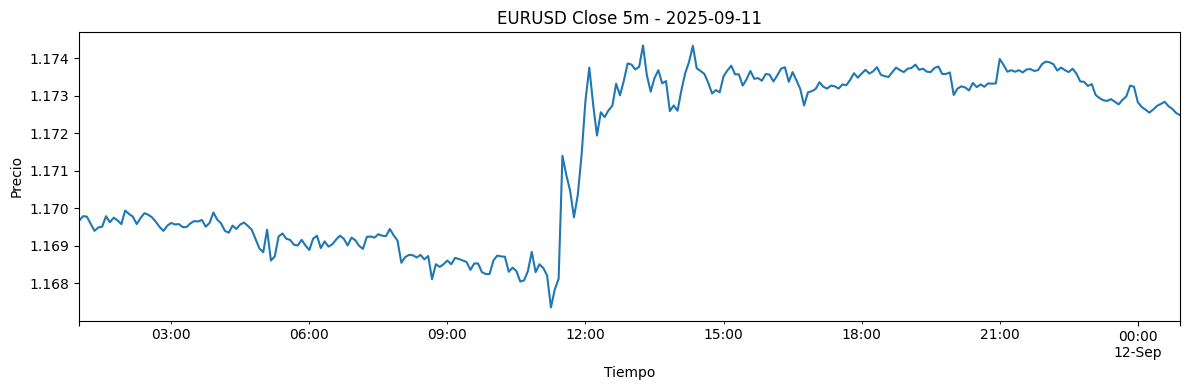

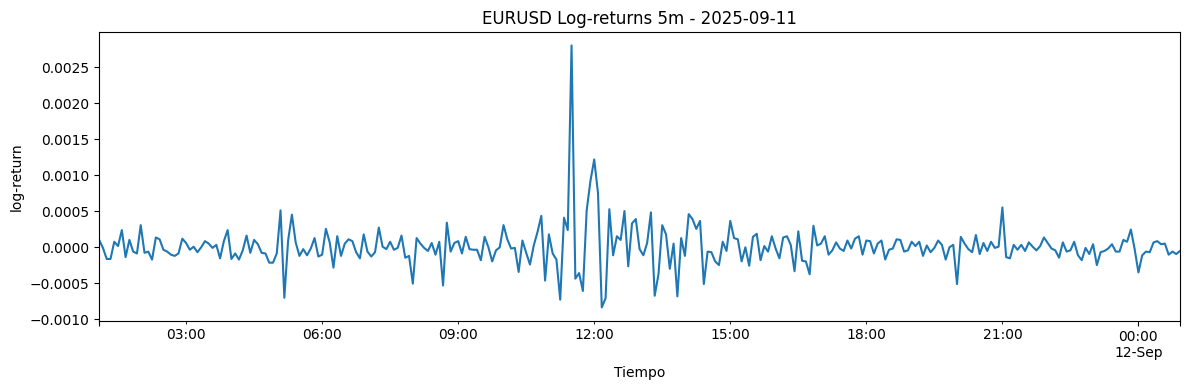

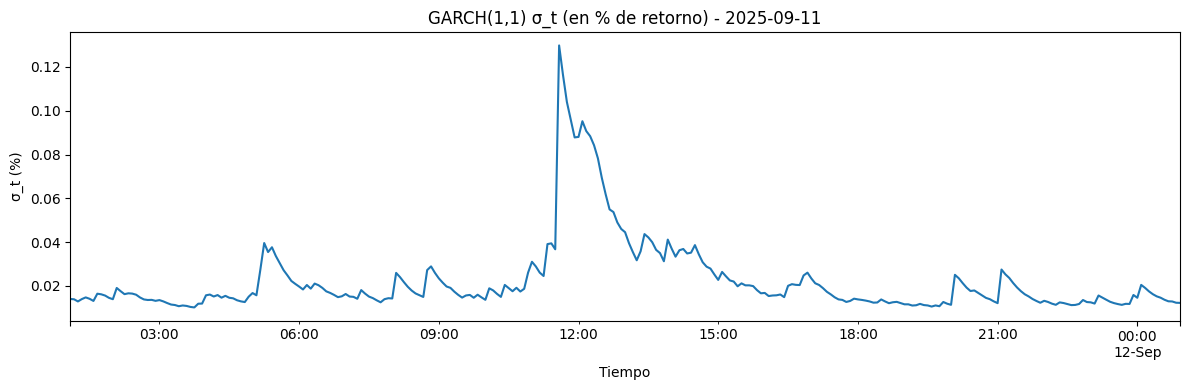

In [26]:

# Precio
ax = df['Close'].plot(figsize=(12,4), title=f"{SYMBOL} Close 5m - {DATE.date()}")
ax.set_xlabel("Tiempo")
ax.set_ylabel("Precio")
plt.tight_layout(); plt.show()

# Retornos
ax = rets.plot(figsize=(12,4), title=f"{SYMBOL} Log-returns 5m - {DATE.date()}")
ax.set_xlabel("Tiempo")
ax.set_ylabel("log-return")
plt.tight_layout(); plt.show()

# Volatilidad condicional si existe
if 'garch_res' in locals() and garch_res is not None:
    ax = garch_res.conditional_volatility.plot(figsize=(12,4),
                                               title=f"GARCH(1,1) σ_t (en % de retorno) - {DATE.date()}")
    ax.set_xlabel("Tiempo")
    ax.set_ylabel("σ_t (%)")
    plt.tight_layout(); plt.show()


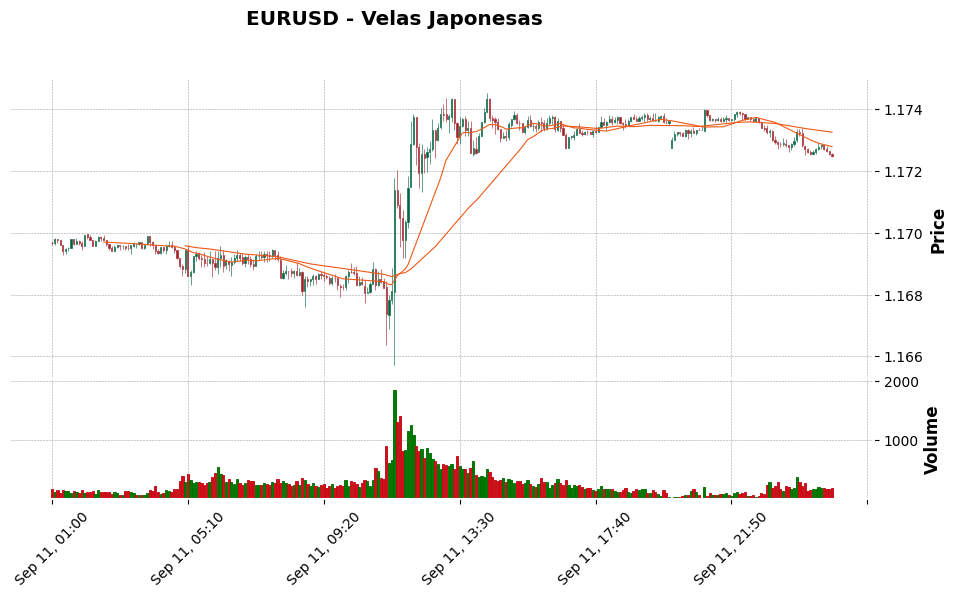

In [29]:
import mplfinance as mpf

# Graficar el DataFrame df en velas japonesas
mpf.plot(df, type='candle', style='charles', title='EURUSD - Velas Japonesas', volume=True, mav=(20,50), figsize=(12,6))

## Pronósticos cortos (ARIMA y GARCH)

In [27]:

# ARIMA forecast
if 'arima_res' in locals() and arima_res is not None:
    try:
        fc = arima_res.get_forecast(steps=3)
        print("Pronóstico ARIMA (retornos próximos 3 pasos):")
        display(fc.summary_frame())
    except Exception as e:
        print(f"Forecast ARIMA falló: {e}")

# GARCH forecast
if 'garch_res' in locals() and garch_res is not None:
    try:
        vf = garch_res.forecast(horizon=3)
        sigma_fut = np.sqrt(vf.variance.values[-1, :])
        print("Pronóstico GARCH σ (próximos 3 pasos, en %):", sigma_fut)
    except Exception as e:
        print(f"Forecast GARCH falló: {e}")


Pronóstico ARIMA (retornos próximos 3 pasos):


ret,mean,mean_se,mean_ci_lower,mean_ci_upper
2025-09-12 01:00:00-04:00,0.000003,0.000287,-0.00056,0.000566
2025-09-12 01:05:00-04:00,0.000003,0.000287,-0.00056,0.000566
2025-09-12 01:10:00-04:00,0.000003,0.000287,-0.00056,0.000566


Pronóstico GARCH σ (próximos 3 pasos, en %): [0.011747   0.01230628 0.01283075]
